# Phase 2 qwen — 실험 결과 종합 분석

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# ── 한국어 폰트 설정 ──
nanum = [f.fname for f in fm.fontManager.ttflist if 'NanumGothic' in f.name]
noto  = [f.fname for f in fm.fontManager.ttflist if 'NotoSansCJK' in f.name or 'Noto Sans CJK' in f.name]

if nanum:
    plt.rcParams['font.family'] = 'NanumGothic'
elif noto:
    plt.rcParams['font.family'] = 'Noto Sans CJK KR'
else:
    print('⚠️ 한국어 폰트를 찾을 수 없습니다. 기본 폰트를 사용합니다.')

plt.rcParams['axes.unicode_minus'] = False

# ── 경로 설정 ──
NOTEBOOK_DIR  = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT  = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..', '..'))
RESULTS_ROOT  = os.path.join(PROJECT_ROOT, 'results', 'phase2_qwen')

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'RESULTS_ROOT : {RESULTS_ROOT}')

# ── 스타일 설정 ──
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── 상수 ──
DATASETS = ['humaneval']
# METHODS  = ['single', 'retry', 'repair','code_then_plan','code_then_plan_repair','policy_loop']
METHODS  = ['single','repair','code_then_plan','code_then_plan_repair','rpe_policy','rpe_policy_v2']
METHOD_LABELS = {
    'single'   : 'Single Shot',
    'repair'   : 'Repair Loop',
    'planner_coder' : 'Planner-Coder',
    'code_then_plan' : 'Code-Then-Plan',
    'code_then_replan' : 'Code-Then-Replan',
    'code_then_plan_repair' : 'Code-Then-Plan+Repair',
    'rpe_policy' : 'Policy Loop'
}

# ── 색상 팔레트 ──
METHOD_COLORS = {
    'single'        : '#4C72B0',
    'repair'       : '#55A868',
    'planner_coder'        : '#C44E52',
    'code_then_plan' : '#8172B2',
    'code_then_replan' : '#9EDDFF',
    'code_then_plan_repair' : '#DD8452',
    'rpe_policy' : '#FFA500'
}

PROJECT_ROOT : /home/dibaeck/workspace/project_IR_focus_sLM_orchestration
RESULTS_ROOT : /home/dibaeck/workspace/project_IR_focus_sLM_orchestration/results/phase2_qwen


---
## 1. 데이터 로드

In [2]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def load_jsonl(path):
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

# ── 결과 로드 ──
summaries          = {}   # (dataset, method) -> summary dict
analyses           = {}   # (dataset, method) -> analysis dict
step_logs_all      = {}   # (dataset, method) -> list of step records
traj_logs_all      = {}   # (dataset, method) -> list of trajectory records
failure_examples_all = {} # (dataset, method) -> dict of failure examples

found = []
missing = []

for dataset in DATASETS:
    for method in METHODS:
        base = os.path.join(RESULTS_ROOT, dataset, method)
        summary_path = os.path.join(base, 'summary.json')
        if os.path.exists(summary_path):
            key = (dataset, method)
            summaries[key]     = load_json(summary_path)
            # analyses[key]      = load_json(os.path.join(base, 'analysis.json'))
            step_logs_all[key] = load_jsonl(os.path.join(base, 'step_logs.jsonl'))
            traj_logs_all[key] = load_jsonl(os.path.join(base, 'trajectory_logs.jsonl'))
            
            fe_path = os.path.join(base, 'failure_examples.json')
            if os.path.exists(fe_path):
                failure_examples_all[key] = load_json(fe_path)
            
            found.append(f'{dataset}/{method}')
        else:
            missing.append(f'{dataset}/{method}')

print(f'✅ 로드 성공 ({len(found)}개):', ', '.join(found))
if missing:
    print(f'⚠️  결과 없음 ({len(missing)}개):', ', '.join(missing))

✅ 로드 성공 (6개): humaneval/single, humaneval/repair, humaneval/code_then_plan, humaneval/code_then_plan_repair, humaneval/rpe_policy, humaneval/rpe_policy_v2


---
## 2-1. 핵심 지표 비교 (pass@1, exec_success_rate, conditional_pass)

In [3]:
# ── summary DataFrame 구성 ──
rows = []
for (dataset, method), s in summaries.items():
    if s is None:
        continue
    row = {
        'dataset'              : dataset,
        'method'               : method,
        'method_label'         : METHOD_LABELS.get(method, method),
        'total'                : s.get('total_problems', s.get('total', 0)),
        'num_pass'             : s.get('num_pass', s.get('passed', 0)),
        'pass@1'               : s.get('pass_at_1', s.get('pass@1', 0.0)),
        'exec_success_rate'    : s.get('execution_success_rate', 0.0),
        'conditional_pass'     : s.get('conditional_pass', 0.0),
        'avg_tokens'           : s.get('avg_tokens', 0.0) or s.get('output', 0.0),
        'avg_latency'          : s.get('avg_latency', 0.0),
        'avg_calls'            : s.get('avg_calls', 0.0),
    }
    rows.append(row)

df_summary = pd.DataFrame(rows)
df_summary = df_summary.set_index(['dataset', 'method'])

# 방법 순서 고정
method_order = [m for m in METHODS if m in df_summary.index.get_level_values('method').unique()]

print('\n=== Summary DataFrame ===')
# display(df_summary[['total', 'num_pass', 'pass@1', 'exec_success_rate', 'conditional_pass',
#                      'avg_tokens', 'avg_latency', 'avg_calls']].round(4))
display(df_summary[['total', 'num_pass', 'pass@1', 'exec_success_rate', 'conditional_pass']].round(4))


=== Summary DataFrame ===


total  num_pass  pass@1  exec_success_rate  \
dataset   method                                                              
humaneval single                   164       109  0.6646             0.8720   
          repair                   164       135  0.8232             0.8659   
          code_then_plan           164       152  0.9268             0.9878   
          code_then_plan_repair    164       151  0.9207             0.9756   
          rpe_policy               164       152  0.9268             0.9939   
          rpe_policy_v2            164       150  0.9146             0.9756   

                                 conditional_pass  
dataset   method                                   
humaneval single                           0.7622  
          repair                           0.9507  
          code_then_plan                   0.9383  
          code_then_plan_repair            0.9438  
          rpe_policy                       0.9325  
          rpe_policy_v2                    0.9375

## 2-2. 토큰 비교

In [4]:
# ── method x stage별 call-level token stats ──
stage_token_rows = []

for dataset in DATASETS:
    for method in METHODS:
        key = (dataset, method)
        steps = pd.DataFrame(step_logs_all.get(key, []))

        if steps.empty or 'stage' not in steps.columns:
            continue

        for stage, g in steps.groupby('stage'):
            stage_token_rows.append({
                'dataset': dataset,
                'method': method,
                'method_label': METHOD_LABELS.get(method, method),
                'stage': stage,
                'num_calls': len(g),

                'input_min': g['input_tokens'].min(),
                'input_avg': g['input_tokens'].mean(),
                'input_max': g['input_tokens'].max(),

                'output_min': g['output_tokens'].min(),
                'output_avg': g['output_tokens'].mean(),
                'output_max': g['output_tokens'].max(),

                'total_min': g['total_tokens'].min(),
                'total_avg': g['total_tokens'].mean(),
                'total_max': g['total_tokens'].max(),
            })

df_stage_token_stats = pd.DataFrame(stage_token_rows)
df_stage_token_stats = df_stage_token_stats.set_index(['dataset', 'method', 'stage'])

display(df_stage_token_stats[
    [
        'num_calls',
        'input_min', 'input_avg', 'input_max',
        'output_min', 'output_avg', 'output_max',
        'total_min', 'total_avg', 'total_max',
    ]
].round(2))

num_calls  input_min  input_avg  \
dataset   method                stage                                        
humaneval single                generate         164         38     134.09   
          repair                generate         164         38     134.09   
                                repair           628        308     735.68   
          code_then_plan        generate         164         38     134.09   
                                plan             171        116     227.19   
                                plan_code        171        182     321.90   
          code_then_plan_repair generate         164         38     134.09   
                                plan             126        116     232.58   
                                plan_code        126        182     329.61   
                                repair            91        275     449.41   
          rpe_policy            generate         164         38     134.09   
                                plan              71        116     364.93   
                                plan_code         71        184     324.17   
                                repair            96        217     615.73   
          rpe_policy_v2         generate         164         38     134.09   
                                plan              53        116     223.45   
                                plan_code         83        182     330.13   
                                repair            26        364     608.23   
                                replan            30        329     589.77   

                                           input_max  output_min  output_avg  \
dataset   method                stage                                          
humaneval single                generate         391          14      160.66   
          repair                generate         391          14      161.24   
                                repair          1350          10      309.69   
          code_then_plan        generate         391          14      163.01   
                                plan             468          29       61.71   
                                plan_code        639          20      102.95   
          code_then_plan_repair generate         391          14      163.41   
                                plan             468          17       64.03   
                                plan_code        642          18       92.71   
                                repair           991           3      113.21   
          rpe_policy            generate         391          14      166.67   
                                plan            1191          26       65.03   
                                plan_code        564          21      105.61   
                                repair          1193           3      281.99   
          rpe_policy_v2         generate         391          14      166.48   
                                plan             468          30       65.85   
                                plan_code        580          17      105.40   
                                repair           943           3      293.88   
                                replan          1348          35       66.83   

                                           output_max  total_min  total_avg  \
dataset   method                stage                                         
humaneval single                generate          512         63     294.76   
          repair                generate          512         63     295.33   
                                repair            512        356    1045.37   
          code_then_plan        generate          512         66     297.10   
                                plan              140        149     288.90   
                                plan_code         512        256     424.85   
          code_then_plan_repair generate          512         63     297.50   
            

In [5]:
display(
    df_stage_token_stats.loc[('humaneval', 'rpe_policy')]
    .round(2)
)

# generate   : 초기 single-shot 비용
# plan       : planner prompt 비용
# plan_code  : plan-conditioned coding 비용
# replan     : failure-aware planning 비용
# replan_code: revised-plan coding 비용
# repair     : feedback-based repair 비용

,method_label,num_calls,input_min,input_avg,input_max,output_min,output_avg,output_max,total_min,total_avg,total_max
stage,,,,,,,,,,,
generate,Policy Loop,164,38,134.09,391,14,166.67,512,63,300.76,713
plan,Policy Loop,71,116,364.93,1191,26,65.03,141,151,429.96,1308
plan_code,Policy Loop,71,184,324.17,564,21,105.61,512,264,429.77,931
repair,Policy Loop,96,217,615.73,1193,3,281.99,512,276,897.72,1705


---
## 3. 방법별 비교 시각화

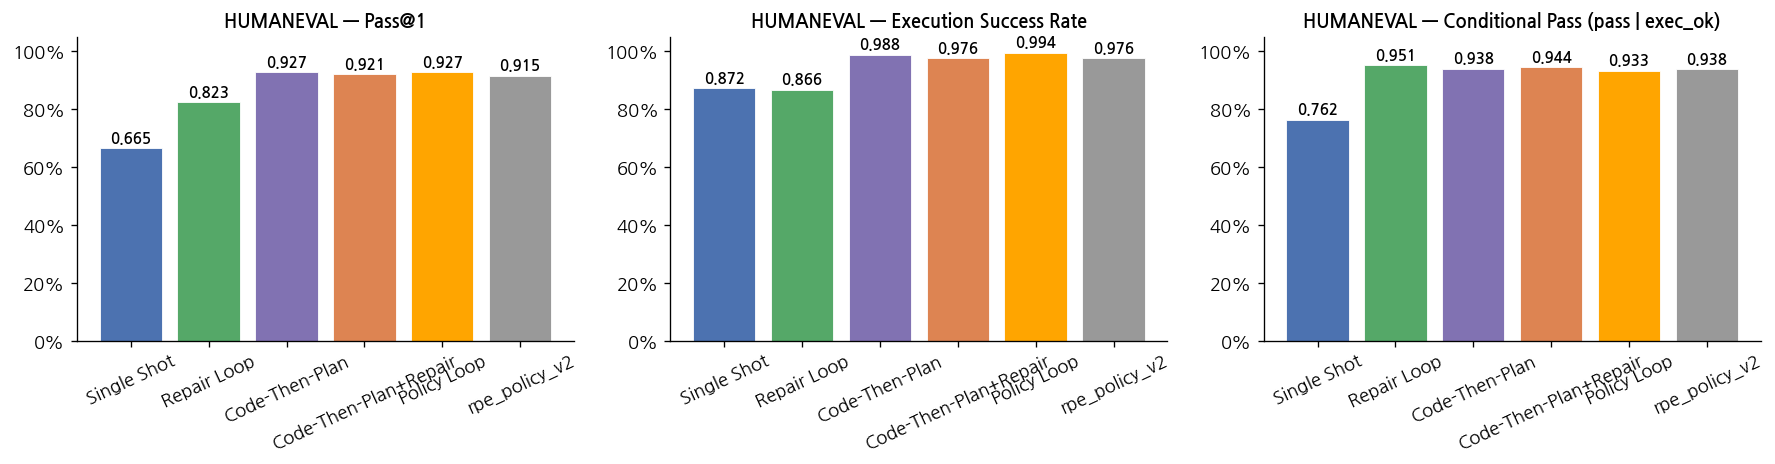

In [6]:
rows = []
for (dataset, method), s in summaries.items():
    rows.append({
        'dataset': dataset,
        'method': method,
        'method_label': METHOD_LABELS.get(method, method),
        'total': s.get('total_problems', s.get('total', 0)),
        'pass': s.get('num_pass', s.get('passed', 0)),
        'pass@1': s.get('pass_at_1', s.get('pass@1', 0)),
        'exec_success_rate': s.get('execution_success_rate', 0),
        'conditional_pass': s.get('conditional_pass', 0),
        'avg_tokens': s.get('avg_tokens', 0),
        'avg_latency': s.get('avg_latency', 0),
        'avg_calls': s.get('avg_calls', 0),
    })

df_summary = pd.DataFrame(rows)

metrics_to_plot = ['pass@1', 'exec_success_rate', 'conditional_pass']
metric_titles = {
    'pass@1': 'Pass@1',
    'exec_success_rate': 'Execution Success Rate',
    'conditional_pass': 'Conditional Pass (pass | exec_ok)',
}

available_datasets = [d for d in DATASETS if any((d,m) in summaries for m in METHODS)]

fig, axes = plt.subplots(len(available_datasets), len(metrics_to_plot),
                         figsize=(5 * len(metrics_to_plot), 4 * len(available_datasets)),
                         squeeze=False)

for row_idx, dataset in enumerate(available_datasets):
    df_ds = df_summary[df_summary['dataset'] == dataset].copy()
    if df_ds.empty:
        continue
    
    for col_idx, metric in enumerate(metrics_to_plot):
        ax = axes[row_idx, col_idx]
        colors = [METHOD_COLORS.get(m, '#999999') for m in df_ds['method']]
        bars = ax.bar(df_ds['method_label'], df_ds[metric], color=colors, edgecolor='white', linewidth=0.5)
        
        # 값 표시
        for bar, val in zip(bars, df_ds[metric]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax.set_title(f'{dataset.upper()} — {metric_titles[metric]}', fontsize=11, fontweight='bold')
        ax.set_ylim(0, 1.05)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
        ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
# plt.savefig(os.path.join(NOTEBOOK_DIR, 'ver4_metrics_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
# print('📊 ver4_metrics_comparison.png 저장 완료')

---
## 4. Failure Type 분석

In [7]:
# 4-1. failure_type_counts (analysis.json)
for dataset in available_datasets:
    print(f'\n{"=" * 60}')
    print(f'📌 {dataset.upper()} — Failure Type Counts')
    print('=' * 60)
    
    for method in METHODS:
        key = (dataset, method)
        if key not in analyses:
            continue
        ftc = analyses[key].get('failure_type_counts', {})
        if not ftc:
            print(f'  {METHOD_LABELS[method]}: (failure 없음)')
            continue
        print(f'\n  {METHOD_LABELS[method]}:')
        for ftype, count in sorted(ftc.items(), key=lambda x: -x[1]):
            print(f'    {ftype}: {count}')


📌 HUMANEVAL — Failure Type Counts


In [8]:
# 4-2. failure_family_counts (analysis.json)
print('\n' + '=' * 60)
print('📌 Failure Family Counts (coarse-grained)')
print('=' * 60)

family_rows = []
for (dataset, method), a in analyses.items():
    ffc = a.get('failure_family_counts', {})
    for family, count in ffc.items():
        family_rows.append({
            'dataset': dataset,
            'method': METHOD_LABELS.get(method, method),
            'failure_family': family,
            'count': count,
        })

if family_rows:
    df_family = pd.DataFrame(family_rows)
    pivot_family = df_family.pivot_table(
        index=['dataset', 'method'], columns='failure_family',
        values='count', fill_value=0, aggfunc='sum'
    )
    display(pivot_family)
else:
    print('  (failure_family_counts 데이터 없음)')


📌 Failure Family Counts (coarse-grained)
  (failure_family_counts 데이터 없음)


In [9]:
# 4-3. Failure Family 시각화 (Stacked Bar)
for dataset in available_datasets:
    family_data = {}
    for method in METHODS:
        key = (dataset, method)
        if key not in analyses:
            continue
        ffc = analyses[key].get('failure_family_counts', {})
        if ffc:
            family_data[METHOD_LABELS[method]] = ffc
    
    if not family_data:
        continue
    
    df_fam = pd.DataFrame(family_data).T.fillna(0)
    
    fig, ax = plt.subplots(figsize=(8, 4))
    df_fam.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white', linewidth=0.5)
    ax.set_title(f'{dataset.upper()} — Failure Family 분포', fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='Failure Family', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 5. Transition Path 분석 (repair / code_then_plan / code_then_replan / code_then_plan_repair / rpe)

In [10]:
# analysis.json의 transition_counts 수집
trans_rows = []
for (dataset, method), an in analyses.items():
    if an is None:
        continue
    tc = an.get('transition_counts', {})
    for trans, cnt in tc.items():
        trans_rows.append({
            'dataset'    : dataset,
            'method'     : method,
            'transition' : trans,
            'count'      : cnt,
        })

df_trans = pd.DataFrame(trans_rows)

if df_trans.empty:
    print('⚠️  transition_counts 데이터가 없습니다.')
else:
    # 방법별로 의미 있는 것: retry / repair / bestofn
    iterative_methods = ['retry', 'repair', 'bestofn','planner_coder']
    for dataset in DATASETS:
        sub = df_trans[(df_trans['dataset'] == dataset) &
                       (df_trans['method'].isin(iterative_methods))]
        if sub.empty:
            continue

        pivot = sub.groupby(['method', 'transition'])['count'].sum().unstack(fill_value=0)
        pivot = pivot.reindex([m for m in iterative_methods if m in pivot.index])
        pivot.index = [METHOD_LABELS.get(m, m) for m in pivot.index]

        print(f'\n[{dataset.upper()}] Transition Counts (retry/repair/bestofn/planner_coder):')
        display(pivot.style.background_gradient(cmap='Blues', axis=None))

        # 핵심 전이: *→PASS (성공 전이)
        success_trans = [c for c in pivot.columns if c.endswith('->PASS')]
        if success_trans:
            print(f'  → PASS 전이 (복구 성공):')
            display(pivot[success_trans])

⚠️  transition_counts 데이터가 없습니다.


In [11]:
def extract_sequence_counts(traj_logs, pattern_len=5, must_include=None, coarse=False):
    seq_counts = {}

    for traj in traj_logs:
        path = traj.get('transition_path', [])

        if coarse:
            states = [p.split(':')[0] for p in path]
        else:
            states = path  # EXEC_FAIL:AssertionError 그대로 사용

        if len(states) < pattern_len:
            continue

        for i in range(len(states) - pattern_len + 1):
            seq = tuple(states[i:i+pattern_len])

            if must_include is not None and must_include not in seq:
                continue

            seq_counts[seq] = seq_counts.get(seq, 0) + 1

    return seq_counts

In [12]:
# 5-3. 최종 상태별 분포 (trajectory_logs의 final_status)
for dataset in available_datasets:
    print(f'\n{"=" * 60}')
    print(f'🎯 {dataset.upper()} — Final Status 분포')
    print('=' * 60)
    
    for method in METHODS:
        key = (dataset, method)
        if key not in traj_logs_all:
            continue
        
        trajs = traj_logs_all[key]
        status_counts = {}
        for t in trajs:
            s = t.get('final_status', 'UNKNOWN')
            status_counts[s] = status_counts.get(s, 0) + 1
        
        print(f'\n  {METHOD_LABELS[method]} (n={len(trajs)}):')
        for s, c in sorted(status_counts.items(), key=lambda x: -x[1]):
            pct = c / len(trajs) * 100
            print(f'    {s}: {c} ({pct:.1f}%)')


🎯 HUMANEVAL — Final Status 분포

  Single Shot (n=164):
    PASS: 109 (66.5%)
    TEST_FAIL:AssertionError: 32 (19.5%)
    EXEC_FAIL:SyntaxError: 16 (9.8%)
    EXEC_FAIL:AssertionError: 2 (1.2%)
    TEST_FAIL:IndexError: 1 (0.6%)
    EXEC_FAIL:ValueError: 1 (0.6%)
    EXEC_FAIL:IndexError: 1 (0.6%)
    TEST_FAIL:NameError: 1 (0.6%)
    EXEC_FAIL:NameError: 1 (0.6%)

  Repair Loop (n=164):
    PASS: 135 (82.3%)
    EXEC_FAIL:NameError: 19 (11.6%)
    TEST_FAIL:AssertionError: 4 (2.4%)
    EXEC_FAIL:SyntaxError: 3 (1.8%)
    TEST_FAIL:TypeError: 1 (0.6%)
    TEST_FAIL:NameError: 1 (0.6%)
    TEST_FAIL:IndexError: 1 (0.6%)

  Code-Then-Plan (n=164):
    PASS: 152 (92.7%)
    TEST_FAIL:AssertionError: 8 (4.9%)
    TEST_FAIL:NameError: 2 (1.2%)
    EXEC_FAIL:NameError: 1 (0.6%)
    EXEC_FAIL:SyntaxError: 1 (0.6%)

  Code-Then-Plan+Repair (n=164):
    PASS: 151 (92.1%)
    TEST_FAIL:AssertionError: 9 (5.5%)
    EXEC_FAIL:SyntaxError: 4 (2.4%)

  Policy Loop (n=164):
    PASS: 152 (92.7%)
    

KeyError: 'rpe_policy_v2'

---
## 6. 토큰 / 레이턴시 효율성 분석

In [ ]:
# 6-1. 방법별 평균 토큰 / 레이턴시 / 호출 횟수 비교
efficiency_rows = []
for (dataset, method), trajs in traj_logs_all.items():
    tokens = [t.get('total_tokens', 0) for t in trajs]
    latencies = [t.get('total_latency', 0) for t in trajs]
    calls = [t.get('call_count', 0) for t in trajs]
    
    efficiency_rows.append({
        'dataset': dataset,
        'method': METHOD_LABELS.get(method, method),
        'avg_tokens': np.mean(tokens) if tokens else 0,
        'std_tokens': np.std(tokens) if tokens else 0,
        'avg_latency': np.mean(latencies) if latencies else 0,
        'std_latency': np.std(latencies) if latencies else 0,
        'avg_calls': np.mean(calls) if calls else 0,
        'med_tokens': np.median(tokens) if tokens else 0,
        'med_latency': np.median(latencies) if latencies else 0,
    })

df_eff = pd.DataFrame(efficiency_rows)
display(df_eff.style.format({
    'avg_tokens': '{:.1f}', 'std_tokens': '{:.1f}',
    'avg_latency': '{:.2f}', 'std_latency': '{:.2f}',
    'avg_calls': '{:.1f}',
    'med_tokens': '{:.1f}', 'med_latency': '{:.2f}',
}).set_caption('토큰 / 레이턴시 효율성'))

In [ ]:
# pass@1 대비 평균 토큰 비용 (효율성)
eff_rows = []
for (dataset, method), s in summaries.items():
    if s is None:
        continue
    p1    = s.get('pass_at_1', s.get('pass@1', 0.0))
    tok   = s.get('avg_tokens', 0.0)
    lat   = s.get('avg_latency', 0.0)
    calls = s.get('avg_calls', 0.0)
    eff_rows.append({
        'dataset'      : dataset,
        'method'       : method,
        'method_label' : METHOD_LABELS.get(method, method),
        'pass@1'       : p1,
        'avg_tokens'   : tok,
        'avg_latency'  : lat,
        'avg_calls'    : calls,
        'pass_per_1k_tokens': (p1 / tok * 1000) if tok > 0 else 0,
    })

df_eff = pd.DataFrame(eff_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def grouped_bar(df_eff, ycol, ylabel, title, ax):
    methods_present = [m for m in METHODS if m in df_eff['method'].values]
    x = np.arange(len(methods_present))
    w = 0.35
    for di, dataset in enumerate(DATASETS):
        sub = df_eff[df_eff['dataset'] == dataset].set_index('method').reindex(methods_present)
        vals = sub[ycol].fillna(0).values
        ax.bar(x + di * w, vals, width=w, label=dataset.upper(), alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(x + w / 2)
    ax.set_xticklabels([METHOD_LABELS.get(m, m) for m in methods_present], rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

grouped_bar(df_eff, 'avg_tokens',   'Avg Tokens / 문제',     'Avg Token 사용량',    axes[0])
grouped_bar(df_eff, 'avg_latency',  'Avg Latency (sec)',      'Avg 레이턴시',        axes[1])
grouped_bar(df_eff, 'avg_calls',    'Avg Model Calls / 문제', 'Avg Call 수',         axes[2])

plt.suptitle('Phase 1 ver3 — 비용 효율성', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('fig_efficiency.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n=== 효율성 지표 테이블 ===')
display(df_eff[['dataset', 'method_label', 'pass@1', 'avg_tokens', 'avg_latency',
                'avg_calls', 'pass_per_1k_tokens']].round(4))

In [ ]:
# 6-2. pass@1 vs avg_tokens 산점도 (효율성 프론티어)
if not df_summary.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    for method in METHODS:
        df_m = df_summary[df_summary['method'] == method]
        if df_m.empty:
            continue
        ax.scatter(
            df_m['avg_tokens'], df_m['pass@1'],
            c=METHOD_COLORS.get(method, '#999'),
            s=100, alpha=0.8, edgecolors='white', linewidth=0.5,
            label=METHOD_LABELS[method], zorder=5,
        )
        # 데이터셋 라벨
        for _, row in df_m.iterrows():
            ax.annotate(row['dataset'], (row['avg_tokens'], row['pass@1']),
                       textcoords='offset points', xytext=(5, 5), fontsize=8, alpha=0.7)
    
    ax.set_xlabel('Avg Tokens per Problem', fontweight='bold')
    ax.set_ylabel('Pass@1', fontweight='bold')
    ax.set_title('효율성 프론티어: Pass@1 vs Avg Tokens', fontweight='bold')
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    plt.tight_layout()
    # plt.savefig(os.path.join(NOTEBOOK_DIR, 'ver4_efficiency_frontier.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('📊 ver4_efficiency_frontier.png 저장 완료')

In [ ]:
# 6-3. 토큰 분포 박스플롯
for dataset in available_datasets:
    token_data = {}
    for method in METHODS:
        key = (dataset, method)
        if key not in traj_logs_all:
            continue
        token_data[METHOD_LABELS[method]] = [t.get('total_tokens', 0) for t in traj_logs_all[key]]
    
    if not token_data:
        continue
    
    fig, ax = plt.subplots(figsize=(8, 4))
    bp = ax.boxplot(token_data.values(), labels=token_data.keys(), patch_artist=True)
    
    colors_list = [METHOD_COLORS.get(m, '#999') for m in METHODS if METHOD_LABELS[m] in token_data]
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_title(f'{dataset.upper()} — 문제당 총 토큰 분포', fontweight='bold')
    ax.set_ylabel('Total Tokens')
    plt.tight_layout()
    plt.show()

---
## 7. Step-level 상세 분석

In [ ]:
# 7-1. Step별 상태 분포
for dataset in available_datasets:
    print(f'\n{"=" * 60}')
    print(f'📋 {dataset.upper()} — Step-level Status 분포')
    print('=' * 60)
    
    for method in METHODS:
        key = (dataset, method)
        if key not in step_logs_all:
            continue
        
        steps = step_logs_all[key]
        status_counts = {}
        for s in steps:
            st = s.get('status', 'UNKNOWN')
            status_counts[st] = status_counts.get(st, 0) + 1
        
        total = len(steps)
        print(f'\n  {METHOD_LABELS[method]} (total steps: {total}):')
        for st, c in sorted(status_counts.items(), key=lambda x: -x[1]):
            pct = c / total * 100
            print(f'    {st}: {c} ({pct:.1f}%)')

In [ ]:
# 7-2. Step별 attempt_idx에 따른 Pass Rate 변화 
multi_step_methods_for_curve = ['retry', 'repair']

for dataset in available_datasets:
    fig, ax = plt.subplots(figsize=(8, 4))
    has_data = False
    
    for method in multi_step_methods_for_curve:
        key = (dataset, method)
        if key not in step_logs_all:
            continue
        
        steps = step_logs_all[key]
        # step_id (= attempt_idx)별 pass rate
        attempt_groups = {}
        for s in steps:
            if s.get('is_planner'):
                continue
            sid = s.get('step_id', s.get('call_index', 0))
            if sid not in attempt_groups:
                attempt_groups[sid] = {'pass': 0, 'total': 0}
            attempt_groups[sid]['total'] += 1
            if s.get('status') == 'PASS':
                attempt_groups[sid]['pass'] += 1
        
        if not attempt_groups:
            continue
        has_data = True
        
        xs = sorted(attempt_groups.keys())
        rates = [attempt_groups[x]['pass'] / attempt_groups[x]['total'] for x in xs]
        
        ax.plot(xs, rates, 'o-', color=METHOD_COLORS.get(method, '#999'),
                label=METHOD_LABELS[method], linewidth=2, markersize=6)
    
    if has_data:
        ax.set_title(f'{dataset.upper()} — Attempt별 누적 Pass Rate', fontweight='bold')
        ax.set_xlabel('Attempt Index')
        ax.set_ylabel('Pass Rate')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
        ax.legend()
        ax.set_xticks(range(max(xs) + 1) if 'xs' in dir() else range(5))
        plt.tight_layout()
        plt.show()

In [ ]:
# 7-3. Step별 토큰 사용량 히트맵
for dataset in available_datasets:
    for method in multi_step_methods_for_curve:
        key = (dataset, method)
        if key not in step_logs_all:
            continue
        
        steps = step_logs_all[key]
        df_steps = pd.DataFrame(steps)
        
        if df_steps.empty or 'step_id' not in df_steps.columns:
            continue
        
        # planner step 제외
        df_code = df_steps[df_steps.get('is_planner', False) != True].copy()
        
        if df_code.empty:
            continue
        
        print(f'\n{dataset.upper()} / {METHOD_LABELS[method]} — Step별 평균 토큰:')
        grouped = df_code.groupby('step_id').agg({
            'total_tokens': ['mean', 'std', 'count'],
            'latency_sec': ['mean', 'std'],
        }).round(1)
        display(grouped)

---
## 8. Failure Breakdown

In [ ]:
# 8-1. extra_summary (summary.json의 failure breakdown)
for dataset in available_datasets:
    print(f'\n{"=" * 60}')
    print(f'🔍 {dataset.upper()} — Failure Breakdown (summary.json)')
    print('=' * 60)
    
    for method in METHODS:
        key = (dataset, method)
        if key not in summaries:
            continue
        
        extra = summaries[key].get('extra_summary', {})
        if not extra:
            print(f'  {METHOD_LABELS[method]}: (extra_summary 없음)')
            continue
        
        print(f'\n  {METHOD_LABELS[method]}:')
        for k, v in extra.items():
            print(f'    {k}: {v}')

In [ ]:
# 8-2. Failure Examples (failure_examples.json) — 유형별 대표 예시
for dataset in available_datasets:
    for method in METHODS:
        key = (dataset, method)
        if key not in failure_examples_all:
            continue
        
        fe = failure_examples_all[key]
        print(f'\n{"=" * 60}')
        print(f'💡 {dataset.upper()} / {METHOD_LABELS[method]} — 실패 유형 대표 예시 ({len(fe)}개 유형)')
        print('=' * 60)
        
        for status, example in fe.items():
            print(f'\n  📌 [{status}]')
            print(f'     problem_id : {example.get("problem_id", "?")}')
            print(f'     attempt    : {example.get("attempt_idx", "?")}')
            print(f'     error_type : {example.get("error_type", "?")}')
            print(f'     error_msg  : {str(example.get("error_message", ""))[:200]}')
            print(f'     raw_text   : {str(example.get("raw_text", ""))[:200]}')
            print(f'     code       : {str(example.get("generated_code", ""))[:200]}')

In [ ]:
# 8-3. Failure Breakdown 비교 시각화
breakdown_metrics = ['code_failed', 'define_test_failed', 'run_test_failed']

for dataset in available_datasets:
    bd_data = {}
    for method in METHODS:
        key = (dataset, method)
        if key not in summaries:
            continue
        extra = summaries[key].get('extra_summary', {})
        if extra:
            bd_data[METHOD_LABELS[method]] = {k: extra.get(k, 0) for k in breakdown_metrics}
    
    if not bd_data:
        continue
    
    df_bd = pd.DataFrame(bd_data).T
    
    fig, ax = plt.subplots(figsize=(8, 4))
    df_bd.plot(kind='bar', ax=ax, colormap='Paired', edgecolor='white', linewidth=0.5)
    ax.set_title(f'{dataset.upper()} — Failure Breakdown 비교', fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='Failure Stage', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()